In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [2]:
import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

TRACK = "team"
RANDOM_STATE = 42

TRAIN_PATH = Path('train_team_track.parquet')
TEST_PATH = Path('test_team_track.parquet')
OUTPUT_PATH = Path('submission_team_track_hybrid_oof_from_notebook.csv')

## Загрузка данных

In [5]:
train_raw = pd.read_parquet(TRAIN_PATH, columns=['route_id', 'timestamp', 'target_2h'])
test_raw = pd.read_parquet(TEST_PATH, columns=['id', 'route_id', 'timestamp'])

train_raw['timestamp'] = pd.to_datetime(train_raw['timestamp'])
test_raw['timestamp'] = pd.to_datetime(test_raw['timestamp'])

train_raw.head().reset_index(drop=True)

,route_id,timestamp,target_2h
0,29,2025-03-01 00:00:00,27.0
1,29,2025-03-01 00:30:00,27.0
2,29,2025-03-01 01:00:00,23.0
3,29,2025-03-01 01:30:00,37.0
4,29,2025-03-01 02:00:00,31.0


In [6]:
test_raw.head().reset_index(drop=True)

,id,route_id,timestamp
0,0,29,2025-05-30 11:00:00
1,1,29,2025-05-30 11:30:00
2,2,29,2025-05-30 12:00:00
3,3,29,2025-05-30 12:30:00
4,4,29,2025-05-30 13:00:00


## EDA

In [7]:
print('Train rows:', f"{len(train_raw):,}")
print('Train routes:', train_raw['route_id'].nunique())
print('Train range:', train_raw['timestamp'].min(), '->', train_raw['timestamp'].max())
print('Test rows:', f"{len(test_raw):,}")
print('Test routes:', test_raw['route_id'].nunique())
print('Test range:', test_raw['timestamp'].min(), '->', test_raw['timestamp'].max())

Train rows: 4,342,000
Train routes: 1000
Train range: 2025-03-01 00:00:00 -> 2025-05-30 10:30:00
Test rows: 10,000
Test routes: 1000
Test range: 2025-05-30 11:00:00 -> 2025-05-30 15:30:00


In [8]:
panel = (
    train_raw
    .pivot(index='timestamp', columns='route_id', values='target_2h')
    .sort_index()
    .astype(float)
)
total_series = panel.sum(axis=1)

print('Panel shape:', panel.shape)
print('Total mean:', round(float(total_series.mean()), 3))
print('Total std:', round(float(total_series.std()), 3))

Panel shape: (4342, 1000)
Total mean: 68745.18
Total std: 7532.879


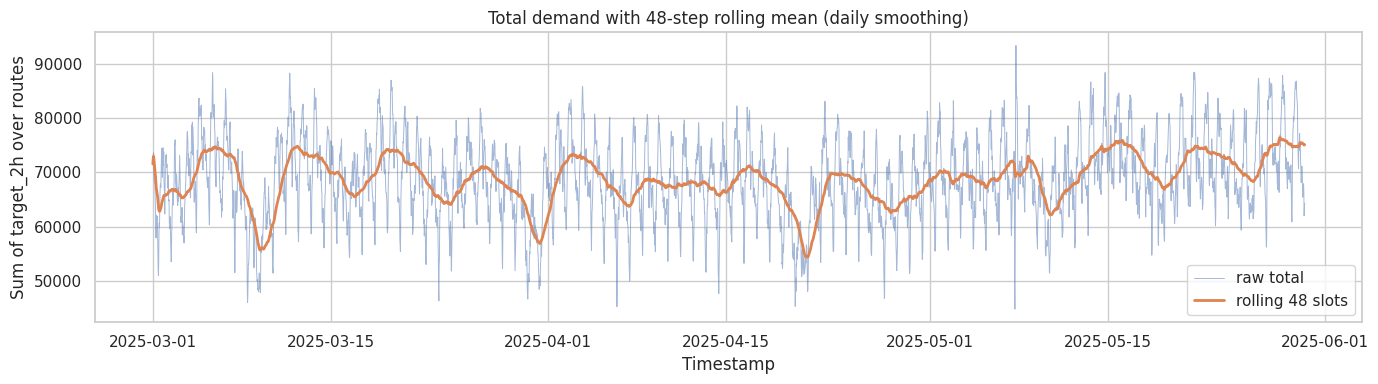

In [9]:
rolling_day = total_series.rolling(48, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(total_series.index, total_series.values, linewidth=0.7, alpha=0.5, label='raw total')
ax.plot(rolling_day.index, rolling_day.values, linewidth=2, label='rolling 48 slots')
ax.set_title('Total demand with 48-step rolling mean (daily smoothing)')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Sum of target_2h over routes')
ax.legend()
plt.tight_layout()
plt.show()

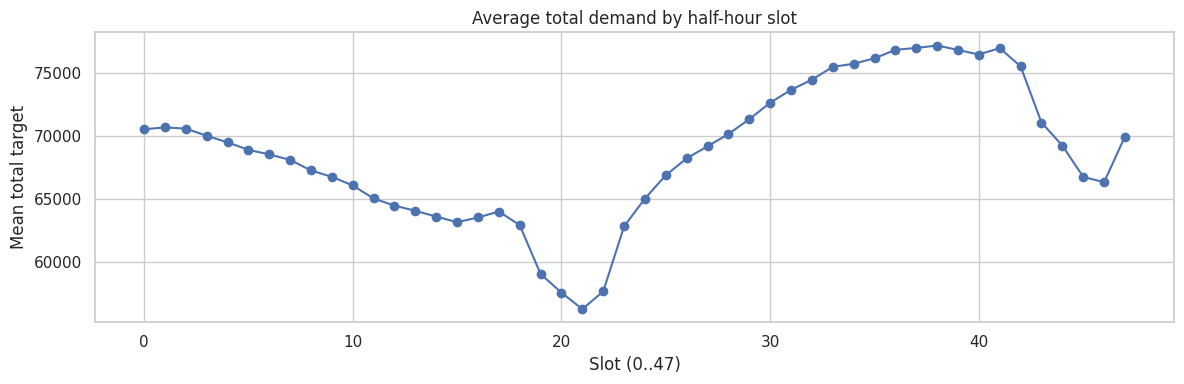

In [10]:
slot = total_series.index.hour * 2 + (total_series.index.minute // 30)
slot_profile = total_series.groupby(slot).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(slot_profile.index, slot_profile.values, marker='o', linewidth=1.5)
ax.set_title('Average total demand by half-hour slot')
ax.set_xlabel('Slot (0..47)')
ax.set_ylabel('Mean total target')
plt.tight_layout()
plt.show()

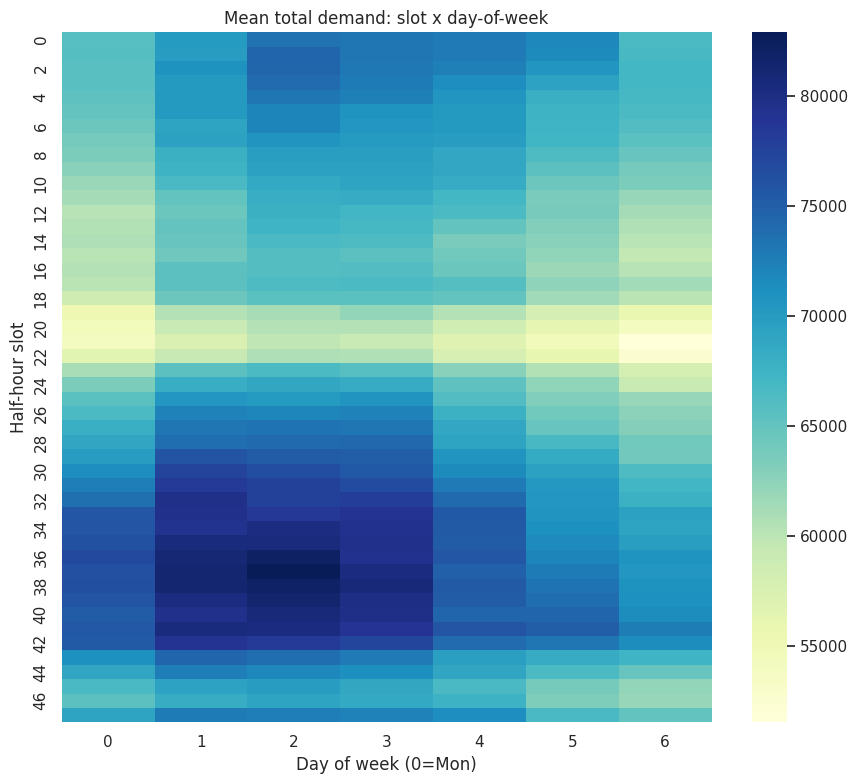

In [11]:
dow = total_series.index.dayofweek
heat_df = pd.DataFrame({'slot': slot, 'dow': dow, 'total': total_series.values})
heat = heat_df.pivot_table(index='slot', columns='dow', values='total', aggfunc='mean')

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(heat, cmap='YlGnBu', ax=ax)
ax.set_title('Mean total demand: slot x day-of-week')
ax.set_xlabel('Day of week (0=Mon)')
ax.set_ylabel('Half-hour slot')
plt.tight_layout()
plt.show()

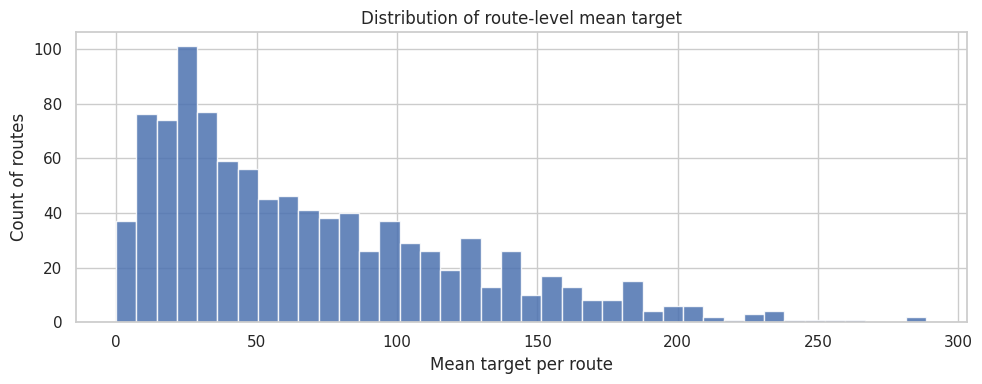

Top-10 routes by mean target:


,mean_target
route_id,
79,288.480424
960,284.372639
956,265.488715
537,254.009212
340,247.232381
827,241.623906
706,237.321511
268,234.660755
641,234.151543


In [12]:
route_mean = panel.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(route_mean.values, bins=40, alpha=0.85)
ax.set_title('Distribution of route-level mean target')
ax.set_xlabel('Mean target per route')
ax.set_ylabel('Count of routes')
plt.tight_layout()
plt.show()

print('Top-10 routes by mean target:')
display(route_mean.sort_values(ascending=False).head(10).to_frame('mean_target'))

In [13]:
peak_slot = int(slot_profile.idxmax())
trough_slot = int(slot_profile.idxmin())
peak_value = float(slot_profile.max())
trough_value = float(slot_profile.min())
ratio = peak_value / max(trough_value, 1e-9)

print(f'Peak slot: {peak_slot}, mean={peak_value:.2f}')
print(f'Trough slot: {trough_slot}, mean={trough_value:.2f}')
print(f'Peak / trough ratio: {ratio:.2f}x')

Peak slot: 38, mean=77198.29
Trough slot: 21, mean=56254.08
Peak / trough ratio: 1.37x


In [14]:
HORIZON = 10        # горизонт прогноза (сколько шагов вперёд предсказываем)
SLOT_COUNT = 48     # количество 30-минутных интервалов в сутках

### Метрика WAPE

In [15]:
def wape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    if denom == 0:
        return float("nan")
    return float(np.sum(np.abs(y_true - y_pred)) / denom)

### Кэш признаков на момент отсечки

Используется для генерации лагов и агрегатов при пошаговом прогнозе без пересчёта всей истории.

In [16]:
@dataclass
class CutoffCache:
    """
    Хранит лаги, скользящие статистики и сезонные агрегаты,
    необходимые для пошагового (autoregressive) прогнозирования.
    """
    lag1: np.ndarray              # значение в предыдущий шаг
    lag2: np.ndarray
    lag3: np.ndarray
    lag4: np.ndarray
    mean4: np.ndarray             # среднее за последние 4 шага
    mean8: np.ndarray
    mean16: np.ndarray
    std8: np.ndarray
    std16: np.ndarray
    route_mean: np.ndarray
    route_mean_share: np.ndarray
    slot_mean: np.ndarray         # среднее по слотам (размер [48, R])
    slot_mean_share: np.ndarray
    total_slot_mean: np.ndarray

In [29]:
@dataclass
class StackCalibration:
  mode: str
  global_scale: float = 1.0
  horizon_scale: np.ndarray | None = None
  horizon_affine_a: np.ndarray | None = None
  hotizon_affine_b: np.ndarray | None = None

In [30]:
def load_panel(train_path: Path) -> Tuple[np.ndarray, np.ndarray, pd.DatetimeIndex, np.ndarray]:
    """
    Загружает данные и преобразует их в панельный формат (время × маршруты).
    """
    train = (
        pd.read_parquet(train_path, columns=["route_id", "timestamp", "target_2h"])
        .sort_values(["timestamp", "route_id"])
        .reset_index(drop=True)
    )
    panel = (
        train.pivot(index="timestamp", columns="route_id", values="target_2h")
        .sort_index()
        .astype(np.float64)
    )
    values = panel.to_numpy(np.float64)
    routes = panel.columns.to_numpy()
    times = panel.index
    slots = (times.hour * 2 + (times.minute // 30)).astype(int)
    return values, routes, times, slots

In [31]:
def get_cutoffs(times: pd.DatetimeIndex, n_time: int, min_lag: int = 336) -> List[int]:
    """
    Определяет моменты отсечки для обучения/валидации.
    Условия:
    - фиксированное время суток
    - достаточно истории для лагов
    - достаточно будущих точек для прогноза
    """
    return [
        i
        for i, t in enumerate(times)
        if t.hour == 11 and t.minute == 0 and i >= min_lag and i + (HORIZON - 1) < n_time
    ]

In [32]:
def make_time_folds(
    cutoffs: List[int],
    n_folds: int,
    val_size: int,           # размер валидационного окна
    min_train_windows: int,  # минимальное число cutoff'ов в обучении
) -> List[Tuple[List[int], List[int]]]:
    """
    Формирует фолды для валидации по временным отсечкам.
    Для каждого фолда:
    - train: все предыдущие cutoff
    - val: следующий блок фиксированного размера
    """
    folds: List[Tuple[List[int], List[int]]] = []
    total_needed = n_folds * val_size
    if len(cutoffs) < min_train_windows + val_size:
        return folds

    start = max(min_train_windows, len(cutoffs) - total_needed)
    for i in range(n_folds):
        val_start = start + i * val_size
        val_end = min(val_start + val_size, len(cutoffs))
        if val_start >= len(cutoffs):
            break
        train = cutoffs[:val_start]
        val = cutoffs[val_start:val_end]
        if len(train) < min_train_windows or len(val) == 0:
            continue
        folds.append((train, val))
    return folds


### Вычисление признаков на момент каждого cutoff

In [33]:
def precompute_cutoff_cache(
    values: np.ndarray,
    slots: np.ndarray,
    cutoffs: List[int],
) -> Dict[int, CutoffCache]:
    """
    Для каждой точки отсечки рассчитываются:
    - лаги (последние значения)
    - скользящие статистики (mean, std)
    - средние по маршрутам и долям
    - сезонные профили по слотам

    Результат сохраняется в кэш для быстрого использования при прогнозировании.
    """
    totals = values.sum(axis=1)
    share = values / np.maximum(totals[:, None], 1e-9)
    route_count = values.shape[1]

    cache: Dict[int, CutoffCache] = {}
    for cut in cutoffs:
        hist = values[:cut]
        hist_share = share[:cut]
        hist_totals = totals[:cut]
        hist_slots = slots[:cut]

        slot_mean = np.zeros((SLOT_COUNT, route_count), dtype=np.float64)
        slot_mean_share = np.zeros((SLOT_COUNT, route_count), dtype=np.float64)
        total_slot_mean = np.zeros(SLOT_COUNT, dtype=np.float64)
        for s in range(SLOT_COUNT):
            idx = np.where(hist_slots == s)[0]
            slot_mean[s] = hist[idx].mean(axis=0)
            slot_mean_share[s] = hist_share[idx].mean(axis=0)
            total_slot_mean[s] = hist_totals[idx].mean()

        cache[cut] = CutoffCache(
            lag1=values[cut - 1].copy(),
            lag2=values[cut - 2].copy(),
            lag3=values[cut - 3].copy(),
            lag4=values[cut - 4].copy(),
            mean4=values[cut - 4 : cut].mean(axis=0),
            mean8=values[cut - 8 : cut].mean(axis=0),
            mean16=values[cut - 16 : cut].mean(axis=0),
            std8=values[cut - 8 : cut].std(axis=0),
            std16=values[cut - 16 : cut].std(axis=0),
            route_mean=hist.mean(axis=0),
            route_mean_share=hist_share.mean(axis=0),
            slot_mean=slot_mean,
            slot_mean_share=slot_mean_share,
            total_slot_mean=total_slot_mean,
        )
    return cache

### Сборка датасета

In [34]:
def build_route_frame(
    values: np.ndarray,
    routes: np.ndarray,
    times: pd.DatetimeIndex,
    slots: np.ndarray,
    totals: np.ndarray,
    share: np.ndarray,
    cache_map: Dict[int, CutoffCache],
    cutoffs: List[int],
    h: int,
) -> pd.DataFrame:
    """
    Формирует обучающую выборку для модели на заданном горизонте h.

    Для каждого cutoff:
    - собираются лаговые признаки и статистики из кэша
    - добавляются временные признаки и сезонность
    - формируется target

    Результат — DataFrame для обучения модели.
    """
    rows = []
    for cut in cutoffs:
        cc = cache_map[cut]
        ti = cut + h
        ts = times[ti]
        s = int(slots[ti])

        # лаги на разных горизонтах (сутки, неделя и т.д.)
        lag48 = values[ti - 48]
        lag96 = values[ti - 96]
        lag144 = values[ti - 144]
        lag336 = values[ti - 336]

        lag48_share = share[ti - 48]
        lag336_share = share[ti - 336]
        target = values[ti]

        df = pd.DataFrame(
            {
                "cut_idx": cut,
                "route_id": routes,
                "dow": int(ts.dayofweek),
                "month": int(ts.month),
                "day": int(ts.day),
                "h": h,
                "lag1": cc.lag1,
                "lag2": cc.lag2,
                "lag3": cc.lag3,
                "lag4": cc.lag4,
                "mean4": cc.mean4,
                "mean8": cc.mean8,
                "mean16": cc.mean16,
                "std8": cc.std8,
                "std16": cc.std16,
                "route_mean": cc.route_mean,
                "lag48": lag48,
                "lag96": lag96,
                "lag144": lag144,
                "lag336": lag336,
                "trend_1d": lag48 - lag96,                  # трендовые признаки
                "trend_1w": lag48 - lag336,
                "slot_mean": cc.slot_mean[s],
                "route_mean_share": cc.route_mean_share,
                "lag48_share": lag48_share,
                "lag336_share": lag336_share,
                "slot_mean_share": cc.slot_mean_share[s],
                "target": target,                           # целевая переменная
                "target_share": target / np.maximum(totals[ti], 1e-9),
            }
        )
        rows.append(df)
    return pd.concat(rows, ignore_index=True)

In [35]:
def build_total_frame(
    values: np.ndarray,
    times: pd.DatetimeIndex,
    slots: np.ndarray,
    totals: np.ndarray,
    cache_map: Dict[int, CutoffCache],
    cutoffs: List[int],
    h: int,
) -> pd.DataFrame:
    """
    Формирует датасет для прогнозирования общего спроса (total).

    Для каждого cutoff:
    - рассчитываются лаги и скользящие статистики total
    - добавляются временные и сезонные признаки
    - формируется целевая переменная target_total
    """
    rows = []
    for cut in cutoffs:
        ti = cut + h
        ts = times[ti]
        s = int(slots[ti])
        cc = cache_map[cut]

        row = {
            "cut_idx": cut,
            "dow": int(ts.dayofweek),
            "month": int(ts.month),
            "day": int(ts.day),
            "h": h,
            "total_lag1": totals[cut - 1],
            "total_lag2": totals[cut - 2],
            "total_lag4_mean": totals[cut - 4 : cut].mean(),
            "total_lag8_mean": totals[cut - 8 : cut].mean(),
            "total_lag16_mean": totals[cut - 16 : cut].mean(),
            # лаги общего спроса на разные горизонты
            "total_lag48": totals[ti - 48],
            "total_lag96": totals[ti - 96],
            "total_lag144": totals[ti - 144],
            "total_lag336": totals[ti - 336],
            "total_slot_mean": cc.total_slot_mean[s],
            # трендовые признаки
            "total_trend_1d": totals[ti - 48] - totals[ti - 96],
            "total_trend_1w": totals[ti - 48] - totals[ti - 336],
            "target_total": totals[ti],
        }
        rows.append(row)
    return pd.DataFrame(rows)

# Обучение

CatBoost (absolute)

In [36]:
def fit_predict_catboost_absolute(
    train_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    iterations: int,
    depth: int,
    learning_rate: float,
) -> np.ndarray:
    """
    Обучает модель CatBoost для предсказания абсолютного значения target
    и возвращает прогноз для pred_df.
    """
    feat_cols = [c for c in train_df.columns if c not in ("target", "target_share", "cut_idx")]
    cat_cols = ["route_id", "dow", "month", "day", "h"]

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        random_seed=42,
        verbose=False,
    )
    model.fit(train_df[feat_cols], train_df["target"], cat_features=cat_cols, verbose=False)
    pred = np.clip(model.predict(pred_df[feat_cols]), 0, None)
    return pred

LGBM (delta)

In [37]:
def fit_predict_lgbm_delta(
    train_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    n_estimators: int,
    num_leaves: int,
    learning_rate: float,
) -> np.ndarray:
    """
    Обучает LightGBM для предсказания изменения (delta) относительно суточного лага (lag48).

    Вместо прямого прогнозирования target модель предсказывает:
    target - lag48, что позволяет лучше учитывать сезонность.

    Финальный прогноз восстанавливается как lag48 + предсказанная delta.
    """
    feat_cols = [
        c for c in train_df.columns if c not in ("target", "target_share", "cut_idx", "route_id")
    ]
    x_train = train_df[feat_cols].copy()
    x_pred = pred_df[feat_cols].copy()
    x_train["route_id"] = train_df["route_id"].astype(np.int32)
    x_pred["route_id"] = pred_df["route_id"].astype(np.int32)
    feat_cols = list(x_train.columns)

    # предсказываем отклонение от суточного значения
    y_delta = train_df["target"].to_numpy() - train_df["lag48"].to_numpy()
    model = LGBMRegressor(
        objective="mae",
        n_estimators=n_estimators,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(x_train[feat_cols], y_delta)
    pred_delta = model.predict(x_pred[feat_cols])
    # восстанавливаем абсолютный прогноз
    pred = np.clip(pred_df["lag48"].to_numpy() + pred_delta, 0, None)
    return pred

Ridge

In [38]:
def fit_predict_ridge_direct(
    train_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    alpha: float,
) -> np.ndarray:
    """
    Обучает линейную модель Ridge для прямого прогнозирования target.
    """
    feat_cols = [
        c for c in train_df.columns if c not in ("target", "target_share", "cut_idx", "route_id")
    ]
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(train_df[feat_cols], train_df["target"])
    pred = np.clip(model.predict(pred_df[feat_cols]), 0, None)
    return pred

Используется двухэтапная модель прогнозирования, которая позволяет лучше учитывать структуру данных и повышает точность прогноза.

In [39]:
def fit_predict_two_stage(
    train_route_df: pd.DataFrame,
    pred_route_df: pd.DataFrame,
    train_total_df: pd.DataFrame,
    pred_total_df: pd.DataFrame,
    cat_iterations: int,
    cat_depth: int,
    cat_lr: float,
    route_count: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Двухэтапная модель прогнозирования:

    1. Прогноз общего спроса (total) с помощью Ridge
    2. Прогноз долей маршрутов (share) с помощью CatBoost

    Финальный прогноз:
    total * нормализованные доли
    """
    # этап 1: прогноз общего спроса
    total_feat = [c for c in train_total_df.columns if c not in ("target_total", "cut_idx")]
    total_model = Ridge(alpha=5.0, random_state=42)
    total_model.fit(train_total_df[total_feat], train_total_df["target_total"])
    total_pred = np.clip(total_model.predict(pred_total_df[total_feat]), 0, None)

    # этап 2: прогноз долей по маршрутам
    share_feat = [
        c
        for c in train_route_df.columns
        if c not in ("target", "target_share", "cut_idx")
    ]
    share_cat = ["route_id", "dow", "month", "day", "h"]
    share_model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=cat_iterations,
        depth=cat_depth,
        learning_rate=cat_lr,
        random_seed=42,
        verbose=False,
    )
    share_model.fit(
        train_route_df[share_feat],
        train_route_df["target_share"],
        cat_features=share_cat,
        verbose=False,
    )
    share_raw = np.clip(share_model.predict(pred_route_df[share_feat]), 0, None)

    # нормализация долей
    pred_route_df_local = pred_route_df[["cut_idx"]].copy()
    pred_route_df_local["share_raw"] = share_raw

    y_pred = np.zeros(len(pred_route_df_local), dtype=np.float64)
    total_by_cut = {
        int(cut): float(total_pred[i]) for i, cut in enumerate(pred_total_df["cut_idx"].to_numpy())
    }
    for cut, idx in pred_route_df_local.groupby("cut_idx").groups.items():
        idx = np.array(list(idx))
        raw = pred_route_df_local.loc[idx, "share_raw"].to_numpy()
        s = raw.sum()
        if s <= 0:
            norm_share = np.full(route_count, 1.0 / route_count, dtype=np.float64)
        else:
            norm_share = raw / s
        y_pred[idx] = total_by_cut[int(cut)] * norm_share

    return np.clip(y_pred, 0, None), np.array(
        [total_by_cut[int(cut)] for cut in pred_route_df["cut_idx"].to_numpy()], dtype=np.float64
    )


In [40]:
def fit_stack_calibration(
    mode: str,
    y_true_by_h: List[np.ndarray],
    y_pred_by_h: List[np.ndarray],
) -> StackCalibration:
    if mode == "none":
        return StackCalibration(mode="none")

    if mode == "global_scale":
        y_true = np.concatenate(y_true_by_h)
        y_pred = np.concatenate(y_pred_by_h)
        scale = float(np.sum(y_true) / max(np.sum(y_pred), 1e-9))
        return StackCalibration(mode=mode, global_scale=scale)

    if mode == "horizon_scale":
        hs = np.ones(HORIZON, dtype=np.float64)
        for h in range(HORIZON):
            hs[h] = float(np.sum(y_true_by_h[h]) / max(np.sum(y_pred_by_h[h]), 1e-9))
        return StackCalibration(mode=mode, horizon_scale=hs)

    if mode == "horizon_affine":
        a = np.ones(HORIZON, dtype=np.float64)
        b = np.zeros(HORIZON, dtype=np.float64)
        for h in range(HORIZON):
            x = y_pred_by_h[h]
            y = y_true_by_h[h]
            x_mean = float(np.mean(x))
            var_x = float(np.var(x))
            if var_x < 1e-9:
                continue
            cov_xy = float(np.mean((x - x_mean) * (y - float(np.mean(y)))))
            ah = cov_xy / var_x
            bh = float(np.mean(y)) - ah * x_mean
            # Conservative clipping to reduce risk of unstable extrapolation on test.
            a[h] = float(np.clip(ah, 0.4, 1.8))
            b[h] = bh
        return StackCalibration(mode=mode, horizon_affine_a=a, horizon_affine_b=b)

    raise ValueError(f"Unsupported calibration mode: {mode}")


In [41]:
def apply_stack_calibration(y_pred: np.ndarray, h: int, calib: StackCalibration) -> np.ndarray:
    if calib.mode == "none":
        return np.clip(y_pred, 0, None)
    if calib.mode == "global_scale":
        return np.clip(y_pred * calib.global_scale, 0, None)
    if calib.mode == "horizon_scale":
        return np.clip(y_pred * float(calib.horizon_scale[h]), 0, None)
    if calib.mode == "horizon_affine":
        return np.clip(
            y_pred * float(calib.horizon_affine_a[h]) + float(calib.horizon_affine_b[h]),
            0,
            None,
        )
    raise ValueError(f"Unsupported calibration mode: {calib.mode}")

In [43]:
import os
import pickle
import joblib
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge


def save_meta_artifacts(
    routes,
    route_groups,
    weights_by_h,
    weights_by_h_group,
    calib,
    route_to_office,
    horizon,
    slot_count,
    output_dir="artifacts/meta",
):
    os.makedirs(output_dir, exist_ok=True)

    meta_artifacts = {
        "routes": routes,
        "route_groups": route_groups,
        "weights_by_h": weights_by_h,
        "weights_by_h_group": weights_by_h_group,
        "calib": calib,
        "route_to_office": route_to_office,
        "horizon": horizon,
        "slot_count": slot_count,
    }

    path = os.path.join(output_dir, "meta_artifacts.pkl")
    with open(path, "wb") as f:
        pickle.dump(meta_artifacts, f)

    print("Saved meta:", path)


def save_models_bundle(
    model_abs_by_h,
    model_delta_by_h,
    model_ridge_by_h,
    model_total_by_h,
    output_dir="artifacts/models",
):
    os.makedirs(output_dir, exist_ok=True)

    for h, model in model_abs_by_h.items():
        model.save_model(os.path.join(output_dir, f"catboost_abs_h{h}.cbm"))

    for h, model in model_delta_by_h.items():
        joblib.dump(model, os.path.join(output_dir, f"lgbm_delta_h{h}.pkl"))

    for h, model in model_ridge_by_h.items():
        joblib.dump(model, os.path.join(output_dir, f"ridge_direct_h{h}.pkl"))

    for h, model in model_total_by_h.items():
        model.save_model(os.path.join(output_dir, f"total_model_h{h}.cbm"))

    print("Saved models to:", output_dir)


def fit_catboost_absolute_model(
    train_df: pd.DataFrame,
    iterations: int,
    depth: int,
    learning_rate: float,
):
    feat_cols = [c for c in train_df.columns if c not in ("target", "target_share", "cut_idx")]
    cat_cols = ["route_id", "dow", "month", "day", "h"]

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        random_seed=42,
        verbose=False,
    )
    model.fit(train_df[feat_cols], train_df["target"], cat_features=cat_cols, verbose=False)
    return model


def fit_lgbm_delta_model(
    train_df: pd.DataFrame,
    n_estimators: int,
    num_leaves: int,
    learning_rate: float,
):
    feat_cols = [
        c for c in train_df.columns if c not in ("target", "target_share", "cut_idx", "route_id")
    ]
    x_train = train_df[feat_cols].copy()
    x_train["route_id"] = train_df["route_id"].astype(np.int32)
    feat_cols = list(x_train.columns)

    y_delta = train_df["target"].to_numpy() - train_df["lag48"].to_numpy()

    model = LGBMRegressor(
        objective="mae",
        n_estimators=n_estimators,
        num_leaves=num_leaves,
        learning_rate=learning_rate,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(x_train[feat_cols], y_delta)
    return model


def fit_ridge_direct_model(
    train_df: pd.DataFrame,
    alpha: float,
):
    feat_cols = [
        c for c in train_df.columns if c not in ("target", "target_share", "cut_idx", "route_id")
    ]
    model = Ridge(alpha=alpha, random_state=42)
    model.fit(train_df[feat_cols], train_df["target"])
    return model


def fit_total_catboost_model(
    train_total_df: pd.DataFrame,
    iterations: int,
    depth: int,
    learning_rate: float,
):
    feat_cols = [c for c in train_total_df.columns if c not in ("target_total", "cut_idx")]

    model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        random_seed=42,
        verbose=False,
    )
    model.fit(train_total_df[feat_cols], train_total_df["target_total"], verbose=False)
    return model

In [45]:
import numpy as np

def build_route_groups(values: np.ndarray, n_groups: int) -> np.ndarray:
    if n_groups <= 1:
        return np.zeros(values.shape[1], dtype=np.int32)
    route_mean = values.mean(axis=0)
    order = np.argsort(route_mean)
    groups = np.zeros(values.shape[1], dtype=np.int32)
    for g, idx in enumerate(np.array_split(order, n_groups)):
        groups[idx] = g
    return groups

In [47]:
import numpy as np

def predict_lag_formula_for_cut(
    values: np.ndarray,
    slots: np.ndarray,
    cut: int,
    cache,
    h: int,
    a: float = 0.6876323378629036,
    b: float = 0.15585209397332267,
    c: float = 0.0632273470621092,
    d: float = 0.12919920398783646,
) -> np.ndarray:
    last = cache.lag1.copy()
    for step in range(h + 1):
        ti = cut + step
        s = int(slots[ti])
        p = a * last + b * values[ti - 48] + c * values[ti - 336] + d * cache.slot_mean[s]
        p = np.clip(p, 0, None)
        last = p
    return last

In [49]:
import numpy as np
from sklearn.linear_model import LinearRegression


def project_to_simplex(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1.0
    idx = np.arange(1, len(v) + 1)
    cond = u - cssv / idx > 0
    rho = np.where(cond)[0][-1]
    theta = cssv[rho] / (rho + 1.0)
    w = np.maximum(v - theta, 0.0)
    return w


def weighted_wape(y_true: np.ndarray, y_pred: np.ndarray, sample_w: np.ndarray) -> float:
    denom = np.sum(sample_w * np.abs(y_true))
    if denom <= 1e-12:
        return float("inf")
    return float(np.sum(sample_w * np.abs(y_true - y_pred)) / denom)


def weighted_mse(y_true: np.ndarray, y_pred: np.ndarray, sample_w: np.ndarray) -> float:
    denom = np.sum(sample_w)
    if denom <= 1e-12:
        return float("inf")
    return float(np.sum(sample_w * (y_true - y_pred) ** 2) / denom)


def score_by_objective(
    objective: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sample_w: np.ndarray,
) -> float:
    if objective == "mse":
        return weighted_mse(y_true, y_pred, sample_w)
    return weighted_wape(y_true, y_pred, sample_w)


def optimize_wape_weights_on_simplex(
    X: np.ndarray,
    y: np.ndarray,
    sample_w: np.ndarray,
    max_iter: int = 280,
    random_trials: int = 500,
) -> np.ndarray:
    n_models = X.shape[1]
    rng = np.random.default_rng(42)

    candidates = [np.full(n_models, 1.0 / n_models)]
    for i in range(n_models):
        one = np.zeros(n_models)
        one[i] = 1.0
        candidates.append(one)

    try:
        meta_mse = LinearRegression(fit_intercept=False, positive=True)
        meta_mse.fit(X, y, sample_weight=sample_w)
        w_mse = np.maximum(meta_mse.coef_, 0.0)
        if np.sum(w_mse) > 0:
            w_mse = w_mse / np.sum(w_mse)
            candidates.append(w_mse)
    except Exception:
        pass

    for _ in range(random_trials):
        candidates.append(rng.dirichlet(np.ones(n_models)))

    best_w = candidates[0]
    best_obj = weighted_wape(y, X @ best_w, sample_w)
    scored = []
    for w in candidates:
        obj = weighted_wape(y, X @ w, sample_w)
        scored.append((obj, w))
        if obj < best_obj:
            best_obj = obj
            best_w = w

    scored.sort(key=lambda z: z[0])
    starts = [scored[i][1] for i in range(min(5, len(scored)))]
    denom = np.sum(sample_w * np.abs(y)) + 1e-12

    for w0 in starts:
        w = w0.copy()
        local_best_w = w.copy()
        local_best_obj = weighted_wape(y, X @ w, sample_w)
        step0 = 0.6
        for t in range(max_iter):
            pred = X @ w
            residual = y - pred
            grad = -(X.T @ (sample_w * np.sign(residual))) / denom
            lr = step0 / np.sqrt(t + 1.0)
            w = project_to_simplex(w - lr * grad)
            obj = weighted_wape(y, X @ w, sample_w)
            if obj < local_best_obj:
                local_best_obj = obj
                local_best_w = w.copy()
        if local_best_obj < best_obj:
            best_obj = local_best_obj
            best_w = local_best_w

    return best_w


def fit_meta_weights_segment(
    X: np.ndarray,
    y: np.ndarray,
    sample_w: np.ndarray,
    objective: str,
    max_iter: int,
    random_trials: int,
    shrink_grid,
) -> np.ndarray:
    if objective == "mse":
        meta = LinearRegression(fit_intercept=False, positive=True)
        meta.fit(X, y, sample_weight=sample_w)
        w_base = np.maximum(meta.coef_, 0.0)
        if np.sum(w_base) <= 0:
            w_base = np.full(X.shape[1], 1.0 / X.shape[1])
        else:
            w_base = w_base / np.sum(w_base)
    else:
        w_base = optimize_wape_weights_on_simplex(
            X=X,
            y=y,
            sample_w=sample_w,
            max_iter=max_iter,
            random_trials=random_trials,
        )

    if not shrink_grid:
        return w_base

    single_scores = [
        score_by_objective(objective, y, X[:, i], sample_w)
        for i in range(X.shape[1])
    ]
    best_idx = int(np.argmin(single_scores))
    one_hot = np.zeros(X.shape[1], dtype=np.float64)
    one_hot[best_idx] = 1.0

    best_w = w_base
    best_score = score_by_objective(objective, y, X @ w_base, sample_w)
    for alpha in shrink_grid:
        w = (1.0 - alpha) * w_base + alpha * one_hot
        score = score_by_objective(objective, y, X @ w, sample_w)
        if score < best_score:
            best_score = score
            best_w = w
    return best_w


def build_meta_sample_weights(
    cut_ids: np.ndarray,
    ordered_cuts,
    recency_decay: float,
) -> np.ndarray:
    if recency_decay <= 0:
        raise ValueError("recency_decay must be positive.")
    if recency_decay == 1.0:
        return np.ones_like(cut_ids, dtype=np.float64)

    cut_to_rank = {int(c): i for i, c in enumerate(ordered_cuts)}
    max_rank = len(ordered_cuts) - 1
    weights = np.array(
        [recency_decay ** (cut_to_rank[int(c)] - max_rank) for c in cut_ids],
        dtype=np.float64,
    )
    return weights


def train_meta_weights_per_h(
    oof_by_model,
    values: np.ndarray,
    oof_cuts,
    model_names,
    route_groups: np.ndarray,
    n_route_groups: int = 1,
    objective: str = "wape",
    recency_decay: float = 1.0,
    max_iter: int = 280,
    random_trials: int = 500,
    shrink_grid=None,
):
    weights = {}
    weights_by_group = {}
    shrink_grid = [0.0] if shrink_grid is None else shrink_grid
    ordered_cuts = sorted(oof_cuts)

    for h in range(HORIZON):
        xs = []
        ys = []
        cut_ids = []

        for cut in oof_cuts:
            y_true = values[cut + h]
            preds = [oof_by_model[name][(cut, h)] for name in model_names]
            x = np.vstack(preds).T
            xs.append(x)
            ys.append(y_true)
            cut_ids.append(np.full(len(y_true), cut, dtype=np.int64))

        X = np.concatenate(xs, axis=0)
        y = np.concatenate(ys, axis=0)
        cut_vec = np.concatenate(cut_ids)
        sample_w = build_meta_sample_weights(cut_vec, ordered_cuts, recency_decay)

        w = fit_meta_weights_segment(
            X=X,
            y=y,
            sample_w=sample_w,
            objective=objective,
            max_iter=max_iter,
            random_trials=random_trials,
            shrink_grid=shrink_grid,
        )
        weights[h] = w

        if n_route_groups <= 1:
            continue

        for g in range(n_route_groups):
            mask_g = route_groups == g
            if not np.any(mask_g):
                weights_by_group[(h, g)] = w
                continue

            xg = []
            yg = []
            cg = []
            for cut in oof_cuts:
                y_true = values[cut + h][mask_g]
                preds = [oof_by_model[name][(cut, h)][mask_g] for name in model_names]
                x = np.vstack(preds).T
                xg.append(x)
                yg.append(y_true)
                cg.append(np.full(len(y_true), cut, dtype=np.int64))

            Xg = np.concatenate(xg, axis=0)
            yg_vec = np.concatenate(yg, axis=0)
            cg_vec = np.concatenate(cg)
            wg = build_meta_sample_weights(cg_vec, ordered_cuts, recency_decay)

            if Xg.shape[0] < max(200, 8 * Xg.shape[1]):
                weights_by_group[(h, g)] = w
                continue

            weights_by_group[(h, g)] = fit_meta_weights_segment(
                X=Xg,
                y=yg_vec,
                sample_w=wg,
                objective=objective,
                max_iter=max_iter,
                random_trials=random_trials,
                shrink_grid=shrink_grid,
            )

    return weights, weights_by_group


def combine_predictions(
    pred_by_model,
    weights_by_h,
    model_names,
    cut: int,
    h: int,
    route_groups: np.ndarray | None = None,
    weights_by_h_group=None,
    n_route_groups: int = 1,
    reconcile_total: float | None = None,
) -> np.ndarray:
    preds = [pred_by_model[name][(cut, h)] for name in model_names]
    X = np.vstack(preds).T

    if route_groups is None or n_route_groups <= 1 or not weights_by_h_group:
        y_hat = X @ weights_by_h[h]
    else:
        y_hat = np.zeros(X.shape[0], dtype=np.float64)
        for g in range(n_route_groups):
            idx = np.where(route_groups == g)[0]
            if len(idx) == 0:
                continue
            w = weights_by_h_group.get((h, g), weights_by_h[h])
            y_hat[idx] = X[idx] @ w

    y_hat = np.clip(y_hat, 0, None)
    if reconcile_total is not None:
        s = float(np.sum(y_hat))
        if s > 0:
            y_hat = y_hat * (float(reconcile_total) / s)
            y_hat = np.clip(y_hat, 0, None)

    return y_hat

In [52]:
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge

def fit_two_stage_models(
    train_route_df: pd.DataFrame,
    train_total_df: pd.DataFrame,
    cat_iterations: int,
    cat_depth: int,
    cat_lr: float,
):
    # total model
    total_feat = [c for c in train_total_df.columns if c not in ("target_total", "cut_idx")]
    total_model = Ridge(alpha=5.0, random_state=42)
    total_model.fit(train_total_df[total_feat], train_total_df["target_total"])

    # share model
    share_feat = [
        c for c in train_route_df.columns
        if c not in ("target", "target_share", "cut_idx")
    ]
    share_cat = ["route_id", "dow", "month", "day", "h"]

    share_model = CatBoostRegressor(
        loss_function="MAE",
        eval_metric="MAE",
        iterations=cat_iterations,
        depth=cat_depth,
        learning_rate=cat_lr,
        random_seed=42,
        verbose=False,
    )
    share_model.fit(
        train_route_df[share_feat],
        train_route_df["target_share"],
        cat_features=share_cat,
        verbose=False,
    )

    return total_model, share_model

In [53]:
def save_two_stage_models_bundle(
    model_two_stage_total_by_h,
    model_two_stage_share_by_h,
    output_dir="artifacts/models",
):
    import os
    import joblib

    os.makedirs(output_dir, exist_ok=True)

    for h, model in model_two_stage_total_by_h.items():
        joblib.dump(model, os.path.join(output_dir, f"two_stage_total_h{h}.pkl"))

    for h, model in model_two_stage_share_by_h.items():
        model.save_model(os.path.join(output_dir, f"two_stage_share_h{h}.cbm"))

    print("Saved two-stage models to:", output_dir)

In [54]:
# ===== paths =====
TRAIN_PATH = Path("train_team_track.parquet")

# ===== final hyperparams =====
N_FOLDS = 4
FOLD_VAL_SIZE = 8
MIN_TRAIN_WINDOWS = 24

CAT_ITER = 350
CAT_DEPTH = 8
CAT_LR = 0.05

LGBM_ESTIMATORS = 450
LGBM_LEAVES = 63
LGBM_LR = 0.05

RIDGE_ALPHA = 10.0

META_ROUTE_GROUPS = 1
META_OBJECTIVE = "wape"
META_RECENCY_DECAY = 1.05
META_OPT_ITERS = 280
META_RANDOM_TRIALS = 500
META_SHRINK_GRID = [0.0, 0.05, 0.1]

DISABLE_RECONCILIATION = False
STACK_POSTCALIBRATION = "none"

# ===== load panel =====
values, routes, times, slots = load_panel(TRAIN_PATH)
totals = values.sum(axis=1)
share = values / np.maximum(totals[:, None], 1e-9)
route_count = values.shape[1]
route_groups = build_route_groups(values, META_ROUTE_GROUPS)

cutoffs = get_cutoffs(times, values.shape[0], min_lag=336)
folds = make_time_folds(
    cutoffs=cutoffs,
    n_folds=N_FOLDS,
    val_size=FOLD_VAL_SIZE,
    min_train_windows=MIN_TRAIN_WINDOWS,
)
if not folds:
    raise ValueError("No valid folds produced.")

oof_cuts = sorted({cut for _, val in folds for cut in val})
cache_map = precompute_cutoff_cache(values, slots, sorted(set(cutoffs + [values.shape[0]])))

model_names = ["lag_formula", "cat_abs", "lgbm_delta", "two_stage", "ridge_direct"]
oof_by_model = {name: {} for name in model_names}
oof_total_two_stage = {}

print(f"Cutoffs total: {len(cutoffs)}")
print(f"Folds: {len(folds)} | OOF cuts: {len(oof_cuts)}")

# ===== OOF generation =====
for fold_id, (train_cuts, val_cuts) in enumerate(folds, start=1):
    print(f"\n[Fold {fold_id}] train_windows={len(train_cuts)} val_windows={len(val_cuts)}")

    for h in range(HORIZON):
        train_route_df = build_route_frame(
            values=values,
            routes=routes,
            times=times,
            slots=slots,
            totals=totals,
            share=share,
            cache_map=cache_map,
            cutoffs=train_cuts,
            h=h,
        )
        val_route_df = build_route_frame(
            values=values,
            routes=routes,
            times=times,
            slots=slots,
            totals=totals,
            share=share,
            cache_map=cache_map,
            cutoffs=val_cuts,
            h=h,
        )
        train_total_df = build_total_frame(
            values=values,
            times=times,
            slots=slots,
            totals=totals,
            cache_map=cache_map,
            cutoffs=train_cuts,
            h=h,
        )
        val_total_df = build_total_frame(
            values=values,
            times=times,
            slots=slots,
            totals=totals,
            cache_map=cache_map,
            cutoffs=val_cuts,
            h=h,
        )

        for cut in val_cuts:
            oof_by_model["lag_formula"][(cut, h)] = predict_lag_formula_for_cut(
                values=values,
                slots=slots,
                cut=cut,
                cache=cache_map[cut],
                h=h,
            )

        cat_pred = fit_predict_catboost_absolute(
            train_df=train_route_df,
            pred_df=val_route_df,
            iterations=CAT_ITER,
            depth=CAT_DEPTH,
            learning_rate=CAT_LR,
        )
        lgb_pred = fit_predict_lgbm_delta(
            train_df=train_route_df,
            pred_df=val_route_df,
            n_estimators=LGBM_ESTIMATORS,
            num_leaves=LGBM_LEAVES,
            learning_rate=LGBM_LR,
        )
        two_pred, two_total = fit_predict_two_stage(
            train_route_df=train_route_df,
            pred_route_df=val_route_df,
            train_total_df=train_total_df,
            pred_total_df=val_total_df,
            cat_iterations=max(120, CAT_ITER // 2),
            cat_depth=max(6, CAT_DEPTH - 1),
            cat_lr=CAT_LR,
            route_count=route_count,
        )
        ridge_pred = fit_predict_ridge_direct(
            train_df=train_route_df,
            pred_df=val_route_df,
            alpha=RIDGE_ALPHA,
        )

        for i, cut in enumerate(val_cuts):
            start = i * route_count
            end = start + route_count
            oof_by_model["cat_abs"][(cut, h)] = np.clip(cat_pred[start:end], 0, None)
            oof_by_model["lgbm_delta"][(cut, h)] = np.clip(lgb_pred[start:end], 0, None)
            oof_by_model["two_stage"][(cut, h)] = np.clip(two_pred[start:end], 0, None)
            oof_by_model["ridge_direct"][(cut, h)] = np.clip(ridge_pred[start:end], 0, None)
            oof_total_two_stage[(cut, h)] = float(np.mean(two_total[start:end]))

# ===== meta weights =====
weights_by_h, weights_by_h_group = train_meta_weights_per_h(
    oof_by_model=oof_by_model,
    values=values,
    oof_cuts=oof_cuts,
    model_names=model_names,
    route_groups=route_groups,
    n_route_groups=META_ROUTE_GROUPS,
    objective=META_OBJECTIVE,
    recency_decay=META_RECENCY_DECAY,
    max_iter=META_OPT_ITERS,
    random_trials=META_RANDOM_TRIALS,
    shrink_grid=META_SHRINK_GRID,
)

# ===== calibration =====
oof_true_by_h = [[] for _ in range(HORIZON)]
oof_base_by_h = [[] for _ in range(HORIZON)]

for cut in oof_cuts:
    for h in range(HORIZON):
        y_true = values[cut + h]
        y_base = combine_predictions(
            pred_by_model=oof_by_model,
            weights_by_h=weights_by_h,
            model_names=model_names,
            cut=cut,
            h=h,
            route_groups=route_groups,
            weights_by_h_group=weights_by_h_group,
            n_route_groups=META_ROUTE_GROUPS,
            reconcile_total=None if DISABLE_RECONCILIATION else oof_total_two_stage.get((cut, h)),
        )
        oof_true_by_h[h].append(y_true)
        oof_base_by_h[h].append(y_base)

calib = fit_stack_calibration(
    mode=STACK_POSTCALIBRATION,
    y_true_by_h=[np.concatenate(v) for v in oof_true_by_h],
    y_pred_by_h=[np.concatenate(v) for v in oof_base_by_h],
)

print("Meta ready")

# ===== final full-train models =====
full_train_cuts = cutoffs
cache_map_full = precompute_cutoff_cache(values, slots, sorted(set(full_train_cuts)))

model_abs_by_h = {}
model_delta_by_h = {}
model_ridge_by_h = {}
model_two_stage_total_by_h = {}
model_two_stage_share_by_h = {}

for h in range(HORIZON):
    print(f"Training final models for horizon {h}...")

    train_route_df = build_route_frame(
        values=values,
        routes=routes,
        times=times,
        slots=slots,
        totals=totals,
        share=share,
        cache_map=cache_map_full,
        cutoffs=full_train_cuts,
        h=h,
    )
    train_total_df = build_total_frame(
        values=values,
        times=times,
        slots=slots,
        totals=totals,
        cache_map=cache_map_full,
        cutoffs=full_train_cuts,
        h=h,
    )

    model_abs_by_h[h] = fit_catboost_absolute_model(
        train_df=train_route_df,
        iterations=CAT_ITER,
        depth=CAT_DEPTH,
        learning_rate=CAT_LR,
    )
    model_delta_by_h[h] = fit_lgbm_delta_model(
        train_df=train_route_df,
        n_estimators=LGBM_ESTIMATORS,
        num_leaves=LGBM_LEAVES,
        learning_rate=LGBM_LR,
    )
    model_ridge_by_h[h] = fit_ridge_direct_model(
        train_df=train_route_df,
        alpha=RIDGE_ALPHA,
    )

    total_model, share_model = fit_two_stage_models(
        train_route_df=train_route_df,
        train_total_df=train_total_df,
        cat_iterations=max(120, CAT_ITER // 2),
        cat_depth=max(6, CAT_DEPTH - 1),
        cat_lr=CAT_LR,
    )
    model_two_stage_total_by_h[h] = total_model
    model_two_stage_share_by_h[h] = share_model

print("Final models trained")

# ===== route -> office =====
train_routes_df = pd.read_parquet(
    TRAIN_PATH,
    columns=["route_id", "office_from_id"]
)
route_to_office = (
    train_routes_df[["route_id", "office_from_id"]]
    .drop_duplicates()
    .set_index("route_id")["office_from_id"]
    .to_dict()
)

# ===== save artifacts =====
save_meta_artifacts(
    routes=routes,
    route_groups=route_groups,
    weights_by_h=weights_by_h,
    weights_by_h_group=weights_by_h_group,
    calib=calib,
    route_to_office=route_to_office,
    horizon=HORIZON,
    slot_count=SLOT_COUNT,
    output_dir="artifacts/meta",
)

save_models_bundle(
    model_abs_by_h=model_abs_by_h,
    model_delta_by_h=model_delta_by_h,
    model_ridge_by_h=model_ridge_by_h,
    model_total_by_h={},  # больше не используем старую total_model_h*.cbm
    output_dir="artifacts/models",
)

save_two_stage_models_bundle(
    model_two_stage_total_by_h=model_two_stage_total_by_h,
    model_two_stage_share_by_h=model_two_stage_share_by_h,
    output_dir="artifacts/models",
)

print("All artifacts saved")

!zip -r artifacts.zip artifacts
print("Archive created: artifacts.zip")

Cutoffs total: 83
Folds: 4 | OOF cuts: 32

[Fold 1] train_windows=51 val_windows=8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5652
[LightGBM] [Info] Number of data points in the train set: 51000, number of used features: 25
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014439 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5652
[LightGBM] [Info] Number of data points in the train set: 51000, number of used features: 25
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5652
[LightGBM] [Info] Number of data points in the train set: 51000, number of used features: 25
[LightGBM] [Info] Auto-choosing col-wise multi-thr